##### Import libraries

In [ ]:
! pip install lime

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from sentence_transformers import models as sentence_models
from sklearn.cluster import AgglomerativeClustering
from collections import Counter
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
import shap
import ast
import joblib
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras import models as keras_models
from tensorflow.keras.utils import plot_model
from lime import lime_tabular
warnings.filterwarnings('ignore')

##### Read data

In [ ]:
data = pd.read_csv("final_ml_data.csv")
data.head()

,subject_id,text,gender,dod,mortality,dischtime,race,marital_status,number_of_readmissions,age_group,stroke_class,admittime_date,blood_pressure,entities
0,10081794,Name: ___ Unit No: ___ Admiss...,F,NaN,0,28/10/2161 15:15,WHITE,DIVORCED,1,65–74,History of TIA,21/10/2161,normal,"['mL: DOSAGE', '50 mcg/: DOSAGE', '25 mg: DOSA..."
1,10083062,Name: ___ Unit No: ___...,F,NaN,0,03/11/2171 19:13,WHITE,SINGLE,0,65–74,History of TIA,31/10/2171,120/50,"['Salmeterol: MEDICATION', '250-50 mcg/Dose: D..."
2,10085941,Name: ___ Unit No: ___ ...,F,18/04/2142,1,21/03/2142 13:30,BLACK/AFRICAN AMERICAN,SINGLE,0,75–84,Hemorrhagic stroke,17/03/2142,125/80,"['100: DOSAGE', 'DAILY: DOSAGE', '10 mg: DOSAG..."
3,10086861,Name: ___ Unit No: __...,F,NaN,0,21/11/2131 18:20,WHITE,MARRIED,0,65–74,Ischemic stroke,20/11/2131,161/64,"['aspirin: MEDICATION', '40 mg daily: DOSAGE',..."
4,10087948,Name: ___ Unit No: ___ ...,M,14/05/2115,1,25/04/2115 14:30,WHITE,MARRIED,0,75–84,History of TIA,21/04/2115,140/78,"['8: DOSAGE', '2 times a day: DOSAGE', '5 mg: ..."


In [ ]:
data.columns

Index(['subject_id', 'text', 'gender', 'dod', 'mortality', 'dischtime', 'race',
       'marital_status', 'number_of_readmissions', 'age_group', 'stroke_class',
       'admittime_date', 'blood_pressure', 'entities'],
      dtype='object')

##### Drop the raw medical text

In [ ]:
data = data[['subject_id','gender', 'dod', 'mortality', 'dischtime', 'race', 'marital_status',
       'number_of_readmissions', 'age_group', 'stroke_class', 'admittime_date', 'blood_pressure', 'entities']]
data.head()

,subject_id,gender,dod,mortality,dischtime,race,marital_status,number_of_readmissions,age_group,stroke_class,admittime_date,blood_pressure,entities
0,10081794,F,NaN,0,28/10/2161 15:15,WHITE,DIVORCED,1,65–74,History of TIA,21/10/2161,normal,"['mL: DOSAGE', '50 mcg/: DOSAGE', '25 mg: DOSA..."
1,10083062,F,NaN,0,03/11/2171 19:13,WHITE,SINGLE,0,65–74,History of TIA,31/10/2171,120/50,"['Salmeterol: MEDICATION', '250-50 mcg/Dose: D..."
2,10085941,F,18/04/2142,1,21/03/2142 13:30,BLACK/AFRICAN AMERICAN,SINGLE,0,75–84,Hemorrhagic stroke,17/03/2142,125/80,"['100: DOSAGE', 'DAILY: DOSAGE', '10 mg: DOSAG..."
3,10086861,F,NaN,0,21/11/2131 18:20,WHITE,MARRIED,0,65–74,Ischemic stroke,20/11/2131,161/64,"['aspirin: MEDICATION', '40 mg daily: DOSAGE',..."
4,10087948,M,14/05/2115,1,25/04/2115 14:30,WHITE,MARRIED,0,75–84,History of TIA,21/04/2115,140/78,"['8: DOSAGE', '2 times a day: DOSAGE', '5 mg: ..."


In [ ]:
data.isnull().sum()

,0
subject_id,0
gender,0
dod,957
mortality,0
dischtime,0
race,0
marital_status,0
number_of_readmissions,0
age_group,0
stroke_class,0


In [ ]:
len(data)

1513

In [ ]:
data["mortality"].value_counts()

,count
mortality,
0,957
1,556


### Data Preprocessing - Feature encoding

##### One-hot encoding for the sex column

In [ ]:
df = pd.get_dummies(data, columns=["gender"], prefix="Sex", drop_first=False, dtype=int)

##### Classify races as "white" and "non-white", then perform one-hot encoding

In [ ]:
df["race"] = df["race"].str.upper()
df["race"] = df["race"].apply(lambda x: "WHITE" if "WHITE" in x else "NON-WHITE")
df["race"].value_counts()

,count
race,
WHITE,1070
NON-WHITE,443


In [ ]:
df = pd.get_dummies(df, columns=["race"], prefix="race", drop_first=False, dtype=int)

##### One-hot encoding for the stroke class and care level (marital status) columns

In [ ]:
df = pd.get_dummies(df, columns=["stroke_class"], prefix="sc", drop_first=False, dtype=int)

In [ ]:
care_level_map = {"SINGLE": "medium", "MARRIED": "high", "WIDOWED": "low", "DIVORCED": "medium"}

In [ ]:
df["marital_status"] = df["marital_status"].map(care_level_map)

In [ ]:
df = pd.get_dummies(df, columns=["marital_status"], prefix="care_level", drop_first=False, dtype=int)

##### Binary encoding for the readmissions column

In [ ]:
df["number_of_readmissions"] = df["number_of_readmissions"].astype(int)
df["readmissions"] = (df["number_of_readmissions"] > 0).astype(int)

##### Classify blood pressure values as normal or abnormal, then perform binary encoding

In [ ]:
def classify_bp(value):
    # Handle nulls safely
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Explicit label handling
    if value in ["normal"]:
        return "normal"
    if value in ["low", "high", "abnormal"]:
        return "abnormal"

    # Numeric BP (e.g. "120/80")
    try:
        systolic, diastolic = map(int, value.split("/"))

        if 91 <= systolic <= 129 and 61 <= diastolic <= 84:
            return "normal"
        else:
            return "abnormal"

    except Exception:
        return "abnormal"


In [ ]:
df["blood_pressure"] = df["blood_pressure"].apply(classify_bp)

In [ ]:
df["blood_pressure"].value_counts()

,count
blood_pressure,
abnormal,1212
normal,301


In [ ]:
df["blood_pressure"] = df["blood_pressure"].map({"abnormal": 1,"normal": 0})

##### Ordinal encoding for the age group column

In [ ]:
df["age_group"].value_counts()

,count
age_group,
75–84,414
65–74,362
45–64,362
85+,306
18–44,69


In [ ]:
age_group_mapping = {"18–44": 1, "45–64": 2, "65–74": 3, "75–84": 4, "85+": 5}

In [ ]:
df["age_group"] = df["age_group"].map(age_group_mapping)

##### Create the entity preprocessing pipeline, which consists of:
1) Using embeddings to select top-K canonical entities per class  
2) Encoding the entities features using class normalized counts and binary presence of the selected canonical entities from step 1

In [ ]:
# Function to create a list of entity dictionaries
def parse_entities(entity_list):
    parsed = []
    for e in entity_list:
        text, cls = e.split(":")
        parsed.append({
            "text": text.strip().lower(),
            "class": cls.strip()
        })
    return parsed

In [ ]:
word_model = sentence_models.Transformer("emilyalsentzer/Bio_ClinicalBERT")
pooling = sentence_models.Pooling(
    word_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True)
bcbert = SentenceTransformer(modules=[word_model, pooling])
def embed_texts(texts):
    return bcbert.encode(texts, normalize_embeddings=True)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# Function to create a cluster of entities within each class
def cluster_entities(entities, distance_threshold=0.25):
    """
    entities: list of dicts with keys ['text', 'class']
    """
    grouped = defaultdict(list)
    for e in entities:
        grouped[e["class"]].append(e["text"])

    canonical_map = {}

    for cls, texts in grouped.items():
        embeddings = embed_texts(texts)

        clustering = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=distance_threshold,
            metric="cosine",
            linkage="average"
        )
        labels = clustering.fit_predict(embeddings)

        clusters = defaultdict(list)
        for text, label in zip(texts, labels):
            clusters[label].append(text)

        # choose canonical name (most frequent or shortest)
        for cluster_texts in clusters.values():
            canonical = sorted(cluster_texts, key=len)[0]
            for t in cluster_texts:
                canonical_map[(t, cls)] = canonical

    return canonical_map

In [ ]:
# Function to build vocabulary of top K words per class
def build_vocabulary(all_entities, canonical_map, top_k=20):
    """
    all_entities: list of parsed entities from training data
    """
    counter = defaultdict(Counter)

    for e in all_entities:
        canonical = canonical_map[(e["text"], e["class"])]
        counter[e["class"]][canonical] += 1

    vocab = {
        cls: [term for term, _ in counts.most_common(top_k)]
        for cls, counts in counter.items()
    }

    return vocab

In [ ]:
# Function to encode entities
def encode_entities(entities, vocab):
    counts = Counter()

    if not isinstance(entities, list):
        return {k: 0.0 for k in vocab}

    for e in entities:
        if not isinstance(e, str):
            continue

        # Split ONLY on the last colon
        parts = e.rsplit(":", 1)
        if len(parts) != 2:
            continue

        cls = parts[1].strip()
        counts[cls] += 1

    total = sum(counts.values()) or 1

    features = {}
    for feature_name, cls in vocab.items():
        features[feature_name] = counts.get(cls, 0) / total

    return features


##### Create the target column: time to mortality

In [ ]:
def remove_time(df, column):
  return df[column].dt.strftime("%Y-%m-%d")

In [ ]:
df["dischtime"] = pd.to_datetime(df["dischtime"])
df["dischtime"] = remove_time(df, "dischtime")

In [ ]:
df["time_to_mortality"] = (pd.to_datetime(df["dod"]) - pd.to_datetime(df["admittime_date"])).dt.days
df["time_to_mortality"] = df["time_to_mortality"].fillna((pd.to_datetime(df["dischtime"]) - pd.to_datetime(df["admittime_date"])).dt.days)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   subject_id                              1513 non-null   int64  
 1   dod                                     556 non-null    object 
 2   mortality                               1513 non-null   int64  
 3   dischtime                               1513 non-null   object 
 4   number_of_readmissions                  1513 non-null   int64  
 5   age_group                               1513 non-null   int64  
 6   admittime_date                          1513 non-null   object 
 7   blood_pressure                          1513 non-null   int64  
 8   entities                                1513 non-null   object 
 9   Sex_F                                   1513 non-null   int64  
 10  Sex_M                                   1513 non-null   int6

In [ ]:
df.head(10)

,subject_id,dod,mortality,dischtime,number_of_readmissions,age_group,admittime_date,blood_pressure,entities,Sex_F,...,sc_Hemorrhagic stroke,sc_Hemorrhagic stroke + history of TIA,sc_History of TIA,sc_Ischemic stroke,sc_Ischemic stroke + history of TIA,care_level_high,care_level_low,care_level_medium,readmissions,time_to_mortality
0,10081794,NaN,0,2161-10-28,1,3,21/10/2161,0,"['mL: DOSAGE', '50 mcg/: DOSAGE', '25 mg: DOSA...",1,...,0,0,1,0,0,0,0,1,1,7.0
1,10083062,NaN,0,2171-11-03,0,3,31/10/2171,1,"['Salmeterol: MEDICATION', '250-50 mcg/Dose: D...",1,...,0,0,1,0,0,0,0,1,0,3.0
2,10085941,18/04/2142,1,2142-03-21,0,4,17/03/2142,0,"['100: DOSAGE', 'DAILY: DOSAGE', '10 mg: DOSAG...",1,...,1,0,0,0,0,0,0,1,0,32.0
3,10086861,NaN,0,2131-11-21,0,3,20/11/2131,1,"['aspirin: MEDICATION', '40 mg daily: DOSAGE',...",1,...,0,0,0,1,0,1,0,0,0,1.0
4,10087948,14/05/2115,1,2115-04-25,0,4,21/04/2115,1,"['8: DOSAGE', '2 times a day: DOSAGE', '5 mg: ...",0,...,0,0,1,0,0,1,0,0,0,23.0
5,10088163,NaN,0,2124-01-27,0,3,25/01/2124,1,"['renal: BIOLOGICAL_STRUCTURE', '\x93: SEVERIT...",0,...,0,0,1,0,0,1,0,0,0,2.0
6,10088799,NaN,0,2168-07-16,0,5,15/07/2168,0,"['shortness of breath: SIGN_SYMPTOM', 'Atenolo...",1,...,0,0,0,1,0,1,0,0,0,1.0
7,10088966,05/06/2132,1,2131-12-13,1,4,29/11/2131,1,"['Atorvastatin: MEDICATION', 'PO: DOSAGE', 'Me...",0,...,0,0,0,1,0,1,0,0,1,189.0
8,10089244,21/02/2128,1,2128-02-21,0,3,09/02/2128,1,"['scopolamine: MEDICATION', 'is: DOSAGE', 'ggt...",1,...,0,0,0,1,0,1,0,0,0,12.0
9,10089730,NaN,0,2134-09-22,0,3,17/09/2134,1,"['mass: SIGN_SYMPTOM', 'hypertrophy: SIGN_SYMP...",1,...,0,0,0,1,0,1,0,0,0,5.0


In [ ]:
df["time_to_mortality"] = df["time_to_mortality"].astype(int)

In [ ]:
df["time_to_mortality"].max()

2650

In [ ]:
print("Latest date of death:", pd.to_datetime(df['dod']).max().strftime("%Y-%m-%d"))
print("Latest date of admission:", pd.to_datetime(df['admittime_date']).max().strftime("%Y-%m-%d"))

Latest date of death: 2207-01-22
Latest date of admission: 2208-10-24


##### Split data into features and target, and training and test set

In [ ]:
df.columns

Index(['subject_id', 'dod', 'mortality', 'dischtime', 'number_of_readmissions',
       'age_group', 'admittime_date', 'blood_pressure', 'entities', 'Sex_F',
       'Sex_M', 'race_NON-WHITE', 'race_WHITE', 'sc_Hemorrhagic stroke',
       'sc_Hemorrhagic stroke + history of TIA', 'sc_History of TIA',
       'sc_Ischemic stroke', 'sc_Ischemic stroke + history of TIA',
       'care_level_high', 'care_level_low', 'care_level_medium',
       'readmissions', 'time_to_mortality'],
      dtype='object')

In [ ]:
ENTITY_CLASSES = ["DOSAGE", "MEDICATION", "SIGN_SYMPTOM", "DISEASE_DISORDER", "BIOLOGICAL_STRUCTURE",
                  "LAB_VALUE", "DIAGNOSTIC_PROCEDURE", "SEVERITY", "THERAPEUTIC_PROCEDURE",
                  "CLINICAL_EVENT", "DETAILED_DESCRIPTION", "DURATION"]
vocab = {f"{cls}": cls for cls in ENTITY_CLASSES}

In [ ]:
df.isnull().sum()

,0
subject_id,0
dod,957
mortality,0
dischtime,0
number_of_readmissions,0
age_group,0
admittime_date,0
blood_pressure,0
entities,0
Sex_F,0


###### Drop features that will not be used for training the model

In [ ]:
X_structured = df.drop(["mortality", "time_to_mortality", "dod", "dischtime", "admittime_date", "number_of_readmissions", "entities"], axis=1)

###### Apply entity preprocessing pipeline

In [ ]:
# Convert each entity to a list
df["entities"] = df["entities"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
### Add code here to execute pipeline

In [ ]:
X_entities = df["entities"].apply(lambda x: encode_entities(x, vocab))
X_entities_df = pd.DataFrame(X_entities.tolist()).fillna(0)

In [ ]:
X = pd.concat([X_structured.reset_index(drop=True), X_entities_df.reset_index(drop=True)], axis=1)

###### Define horizons and create target for each horizon, split data into training and test sets

In [ ]:
horizons = [1, 15, 30, 45, 60, 90]

In [ ]:
targets = {}
for h in horizons:
    # Patient died by day h: only if mortality=1 AND time_to_mortality <= h
    died_by_h = (df['mortality'] == 1) & (df['time_to_mortality'] <= h)

    # Censored before day h: patient left hospital/censored before we could observe day h
    censored_before_h = (df['mortality'] == 0) & (df['time_to_mortality'] < h)

    # Create target: 1 if died, 0 if alive at day h
    # Exclude patients censored before day h (we don't know their status)
    targets[f'died_by_day_{h}'] = died_by_h.astype(int)
    targets[f'observable_at_day_{h}'] = ~censored_before_h  # Can we observe this patient at day h?

In [ ]:
y_df = pd.DataFrame(targets)

In [ ]:
print("\nTarget Distribution:")
for h in horizons:
    observable = y_df[f'observable_at_day_{h}'].sum()
    deaths = y_df.loc[y_df[f'observable_at_day_{h}'], f'died_by_day_{h}'].sum()
    rate = deaths / observable if observable > 0 else 0
    print(f"Day {h:3d}: {deaths:4d} deaths / {observable:4d} observable = {rate:.1%} death rate")


Target Distribution:
Day   1:   45 deaths / 1497 observable = 3.0% death rate
Day  15:  249 deaths /  627 observable = 39.7% death rate
Day  30:  319 deaths /  565 observable = 56.5% death rate
Day  45:  367 deaths /  559 observable = 65.7% death rate
Day  60:  386 deaths /  556 observable = 69.4% death rate
Day  90:  415 deaths /  556 observable = 74.6% death rate


In [ ]:
patient_ids = df["subject_id"].unique()
train_patients, test_patients = train_test_split(
    patient_ids, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
train_mask = df["subject_id"].isin(train_patients)
test_mask = df["subject_id"].isin(test_patients)

In [ ]:
X_train = X[train_mask].reset_index(drop=True)
X_test = X[test_mask].reset_index(drop=True)
y_train_df = y_df[train_mask].reset_index(drop=True)
y_test_df = y_df[test_mask].reset_index(drop=True)

In [ ]:
print("Length of training set: ", len(X_train))
print("Length of test set: ", len(X_test))

Length of training set:  1210
Length of test set:  303


In [ ]:
X_train = X_train.drop('subject_id', axis=1)
X_test = X_test.drop('subject_id', axis=1)

In [ ]:
y_train_dict = {}
y_test_dict = {}

In [ ]:
for h in horizons:
    # Get observable patients at this horizon
    train_observable = y_train_df[f'observable_at_day_{h}']
    test_observable = y_test_df[f'observable_at_day_{h}']

    # For neural network, we'll use ALL patients but mask loss for unobservable ones
    # Create targets (1 for died, 0 for survived/censored)
    y_train_dict[h] = y_train_df[f'died_by_day_{h}'].values
    y_test_dict[h] = y_test_df[f'died_by_day_{h}'].values

In [ ]:
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Horizons: {horizons}")

Training samples: 1210
Test samples: 303
Number of features: 27
Horizons: [1, 15, 30, 45, 60, 90]


###### Feature scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_test_scaled

array([[ 0.55185219,  0.50902367,  0.98360545, ..., -0.14763987,
        -0.51639112, -0.19192931],
       [-1.15156912,  0.50902367,  0.98360545, ..., -0.14763987,
        -0.51639112, -0.19192931],
       [ 0.55185219,  0.50902367,  0.98360545, ..., -0.14763987,
        -0.51639112, -0.19192931],
       ...,
       [-0.29985846,  0.50902367, -1.01666781, ..., -0.14763987,
        -0.51639112, -0.19192931],
       [-0.29985846,  0.50902367,  0.98360545, ..., -0.14763987,
        -0.51639112, -0.19192931],
       [-0.29985846,  0.50902367,  0.98360545, ..., -0.14763987,
        -0.51639112, -0.19192931]])

In [ ]:
print(f"  Mean: {X_train_scaled.mean():.4f}")
print(f"  Std: {X_train_scaled.std():.4f}")

  Mean: 0.0000
  Std: 1.0000


In [ ]:
# Convert to proper format for multi-output model
y_train_multi = [y_train_dict[h] for h in horizons]
y_test_multi = [y_test_dict[h] for h in horizons]

In [ ]:
X_export = pd.concat([X_train, X_test], axis=0)
X_export.head()
X_export.to_csv("X_export.csv")

###### Define model architecture

In [ ]:
def build_multitask_model(input_dim, horizons, architecture='standard'):
    """
    Build multi-task neural network for mortality prediction

    Args:
        input_dim: Number of input features
        horizons: List of time horizons
        architecture: 'standard' or 'residual'
    """
    # Input layer
    inputs = layers.Input(shape=(input_dim,), name='patient_features')

    # Batch normalization
    x = layers.BatchNormalization(name='input_batch_norm')(inputs)

    # Shared layers - learn common representations
    x = layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001),
        name='shared_dense_1'
    )(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)
    x = layers.BatchNormalization(name='batch_norm_1')(x)

    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001),
        name='shared_dense_2'
    )(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)
    x = layers.BatchNormalization(name='batch_norm_2')(x)

    x = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001),
        name='shared_dense_3'
    )(x)
    x = layers.Dropout(0.3, name='dropout_3')(x)

    # Task-specific heads - one for each time horizon
    outputs = []
    for h in horizons:
        # Specialized layer for this horizon
        task_specific = layers.Dense(
            32,
            activation='relu',
            kernel_regularizer=regularizers.l2(0.001),
            name=f'task_dense_day_{h}'
        )(x)

        # Output layer (sigmoid for probability)
        output = layers.Dense(
            1,
            activation='sigmoid',
            name=f'output_day_{h}'
        )(task_specific)

        outputs.append(output)

    # Create model
    model = keras_models.Model(inputs=inputs, outputs=outputs, name='multitask_mortality_model')

    return model

In [ ]:
# Build model
model = build_multitask_model(X_train_scaled.shape[1], horizons)

In [ ]:
print("\nModel Architecture:")
model.summary()


Model Architecture:


Model: "multitask_mortality_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patient_features    │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_batch_norm    │ (None, 27)        │        108 │ patient_features… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 256)       │      7,168 │ input_batch_norm… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ shared_dense_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_1        │ (None, 256)       │      1,024 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 128)       │     32,896 │ batch_norm_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ shared_dense_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_2        │ (None, 128)       │        512 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_3      │ (None, 64)        │      8,256 │ batch_norm_2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ shared_dense_3[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ task_dense_day_1    │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ task_dense_day_15   │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ task_dense_day_30   │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ task_dense_day_45   │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ task_dense_day_60   │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ task_dense_day_90   │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_day_1        │ (None, 1)         │         33 │ task_dense_day_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_day_15       │ (None, 1)         │         33 │ task_dense_day_1

 Total params: 62,642 (244.70 KB)

 Trainable params: 61,820 (241.48 KB)

 Non-trainable params: 822 (3.21 KB)

In [ ]:
# Visualize architecture
try:
    plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        dpi=500
    )
    print("Model architecture diagram saved to 'model_architecture.png'")
except:
    print("Could not save model diagram (requires graphviz)")


Model architecture diagram saved to 'model_architecture.png'


In [ ]:
# Create loss dictionary (one loss per output)
losses = {f'output_day_{h}': 'binary_crossentropy' for h in horizons}

In [ ]:
# Create metrics dictionary
metrics = {f'output_day_{h}': ['accuracy', tf.keras.metrics.AUC(name='auc')] for h in horizons}

In [ ]:
adam_optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam_optimizer, loss=losses, metrics=metrics)

###### Define callbacks

In [ ]:
# Callbacks
callback_list = [
    # Early stopping
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate on plateau
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    ),

    # Model checkpoint
    callbacks.ModelCheckpoint(
        'best_mortality_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # CSV logger
    callbacks.CSVLogger('training_history.csv')
]

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train_multi,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callback_list,
    verbose=1
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6718 - output_day_15_accuracy: 0.3350 - output_day_15_auc: 0.4670 - output_day_15_loss: 1.0130 - output_day_1_accuracy: 0.3254 - output_day_1_auc: 0.4543 - output_day_1_loss: 0.9904 - output_day_30_accuracy: 0.7229 - output_day_30_auc: 0.4762 - output_day_30_loss: 0.6024 - output_day_45_accuracy: 0.5269 - output_day_45_auc: 0.4915 - output_day_45_loss: 0.7659 - output_day_60_accuracy: 0.3584 - output_day_60_auc: 0.5096 - output_day_60_loss: 0.9704 - output_day_90_accuracy: 0.4596 - output_day_90_auc: 0.5222 - output_day_90_loss: 0.7702
Epoch 1: val_loss improved from inf to 4.71576, saving model to best_mortality_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - loss: 5.6686 - output_day_15_accuracy: 0.3349 - output_day_15_auc: 0.4666 - output_day_15_loss: 1.0129 - output_day_1_accuracy: 0.3262 - output_day_1_auc: 0.4537 - output_day_1_loss: 0.9891 - output_day_30_accuracy: 0.7233 - output_day_30_auc: 0.4770 - output_da

###### Functions to create model-performance visualizations

In [ ]:
def plot_training_history(history, horizons):
    """Plot training and validation loss/metrics"""

    # Overall loss
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Total loss
    ax = axes[0, 0]
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Overall Training Loss', fontweight='bold', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # AUC for each horizon
    ax = axes[0, 1]
    for h in horizons:
        if f'output_day_{h}_auc' in history.history:
            ax.plot(history.history[f'output_day_{h}_auc'],
                   label=f'Day {h}', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_title('Training AUC by Horizon', fontweight='bold', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Validation AUC for each horizon
    ax = axes[1, 0]
    for h in horizons:
        if f'val_output_day_{h}_auc' in history.history:
            ax.plot(history.history[f'val_output_day_{h}_auc'],
                   label=f'Day {h}', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_title('Validation AUC by Horizon', fontweight='bold', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Learning rate
    ax = axes[1, 1]
    if 'lr' in history.history:
        ax.plot(history.history['lr'])
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate')
        ax.set_title('Learning Rate Schedule', fontweight='bold', fontsize=14)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Learning rate not logged',
               ha='center', va='center', transform=ax.transAxes)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=500, bbox_inches='tight')
    plt.show()

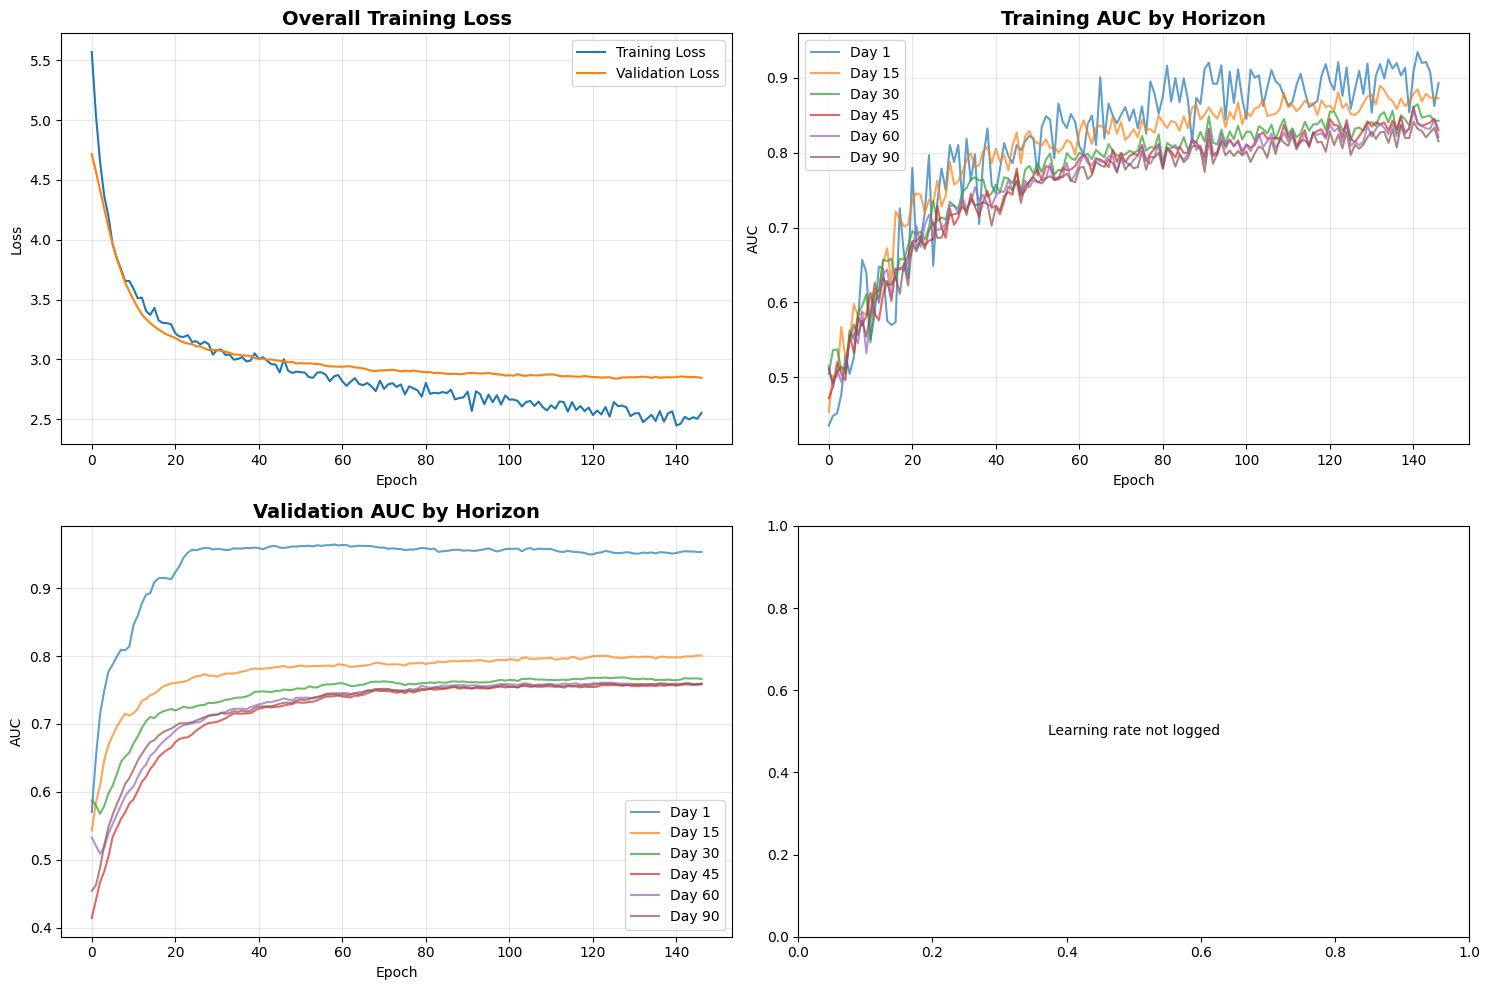

In [ ]:
plot_training_history(history, horizons)

In [ ]:
y_pred_multi = model.predict(X_test_scaled, verbose=0)

In [ ]:
type(y_pred_multi)

list

In [ ]:
len(y_pred_multi)

6

In [ ]:
y_pred_multi.shape

(6, 303, 1)

In [ ]:
arr_2d = y_pred_multi.squeeze(-1)
print(arr_2d.shape)

(6, 303)


In [ ]:
with open("output.txt", "w") as f:
    for row in arr_2d.T:
        clean_row = [float(x) for x in row]
        f.write(str(clean_row) + "\n")

In [ ]:
results = []
for idx, h in enumerate(horizons):
    y_true = y_test_multi[idx]
    y_pred_proba = y_pred_multi[idx].flatten()
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # AUC
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_pred_proba)
    else:
        auc = np.nan

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    results.append({
        'Horizon': f'{h} days',
        'AUC': auc,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'PPV': ppv,
        'NPV': npv,
        'Accuracy': accuracy
    })
    print(f"\nDay {h:3d} Performance:")
    print(f"  AUC: {auc:.3f}")
    print(f"  Sensitivity: {sensitivity:.3f}")
    print(f"  Specificity: {specificity:.3f}")
    print(f"  Accuracy: {accuracy:.3f}")


Day   1 Performance:
  AUC: 0.858
  Sensitivity: 0.000
  Specificity: 1.000
  Accuracy: 0.967

Day  15 Performance:
  AUC: 0.813
  Sensitivity: 0.333
  Specificity: 0.944
  Accuracy: 0.835

Day  30 Performance:
  AUC: 0.784
  Sensitivity: 0.410
  Specificity: 0.917
  Accuracy: 0.815

Day  45 Performance:
  AUC: 0.759
  Sensitivity: 0.443
  Specificity: 0.884
  Accuracy: 0.782

Day  60 Performance:
  AUC: 0.747
  Sensitivity: 0.365
  Specificity: 0.921
  Accuracy: 0.785

Day  90 Performance:
  AUC: 0.749
  Sensitivity: 0.468
  Specificity: 0.875
  Accuracy: 0.769


In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv('deep_learning_results.csv', index=False)

In [ ]:
def plot_roc_curves_dl(y_test_multi, y_pred_multi, horizons):
    """Plot ROC curves for all horizons"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, h in enumerate(horizons):
        ax = axes[idx]

        y_true = y_test_multi[idx]
        y_pred_proba = y_pred_multi[idx].flatten()

        if len(np.unique(y_true)) > 1:
            fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
            auc = roc_auc_score(y_true, y_pred_proba)

            ax.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.3f}', color='#00B1A4')
            ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
            ax.set_xlabel('False Positive Rate', fontweight='bold')
            ax.set_ylabel('True Positive Rate', fontweight='bold')
            ax.set_title(f'Day {h} - ROC Curve', fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
            ax.set_title(f'Day {h}')

    plt.tight_layout()
    plt.savefig('deep_learning_roc_curves.png', dpi=500, bbox_inches='tight')
    plt.show()

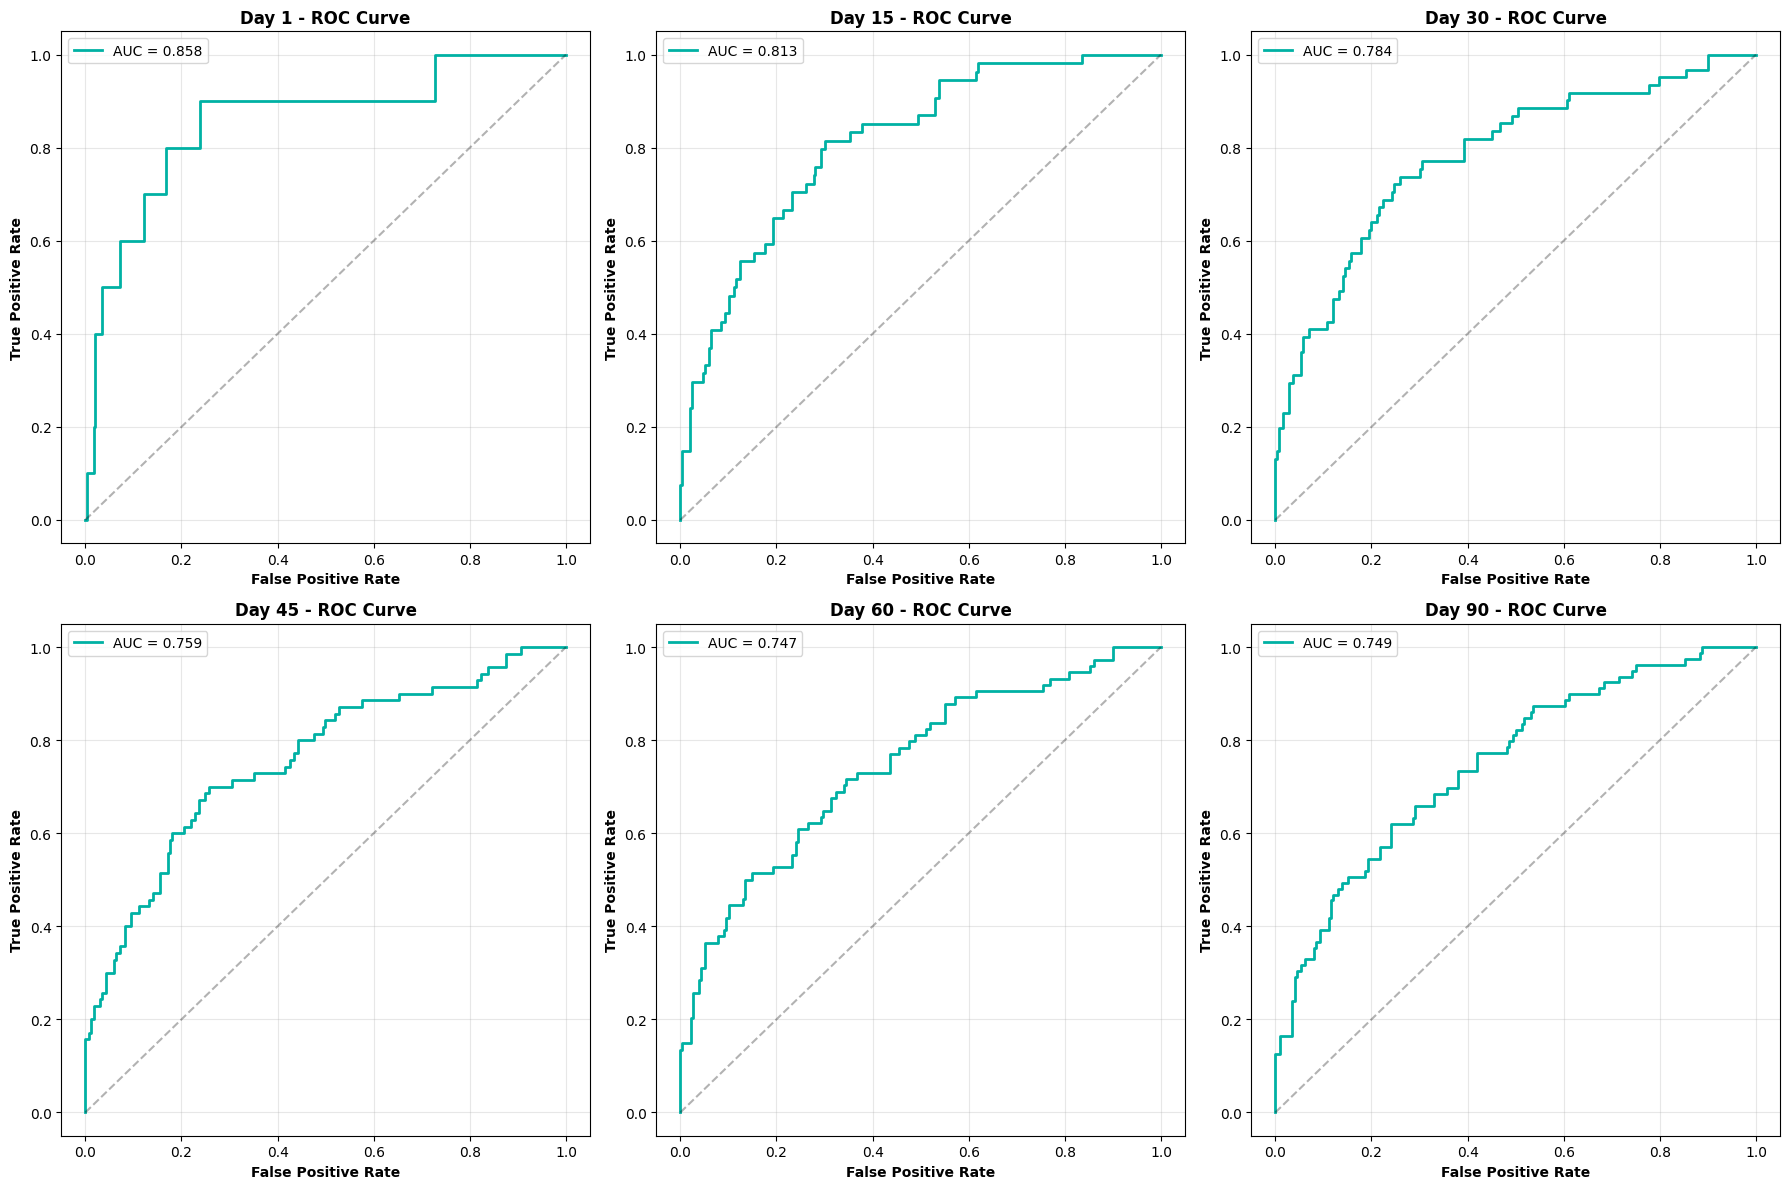

In [ ]:
plot_roc_curves_dl(y_test_multi, y_pred_multi, horizons)

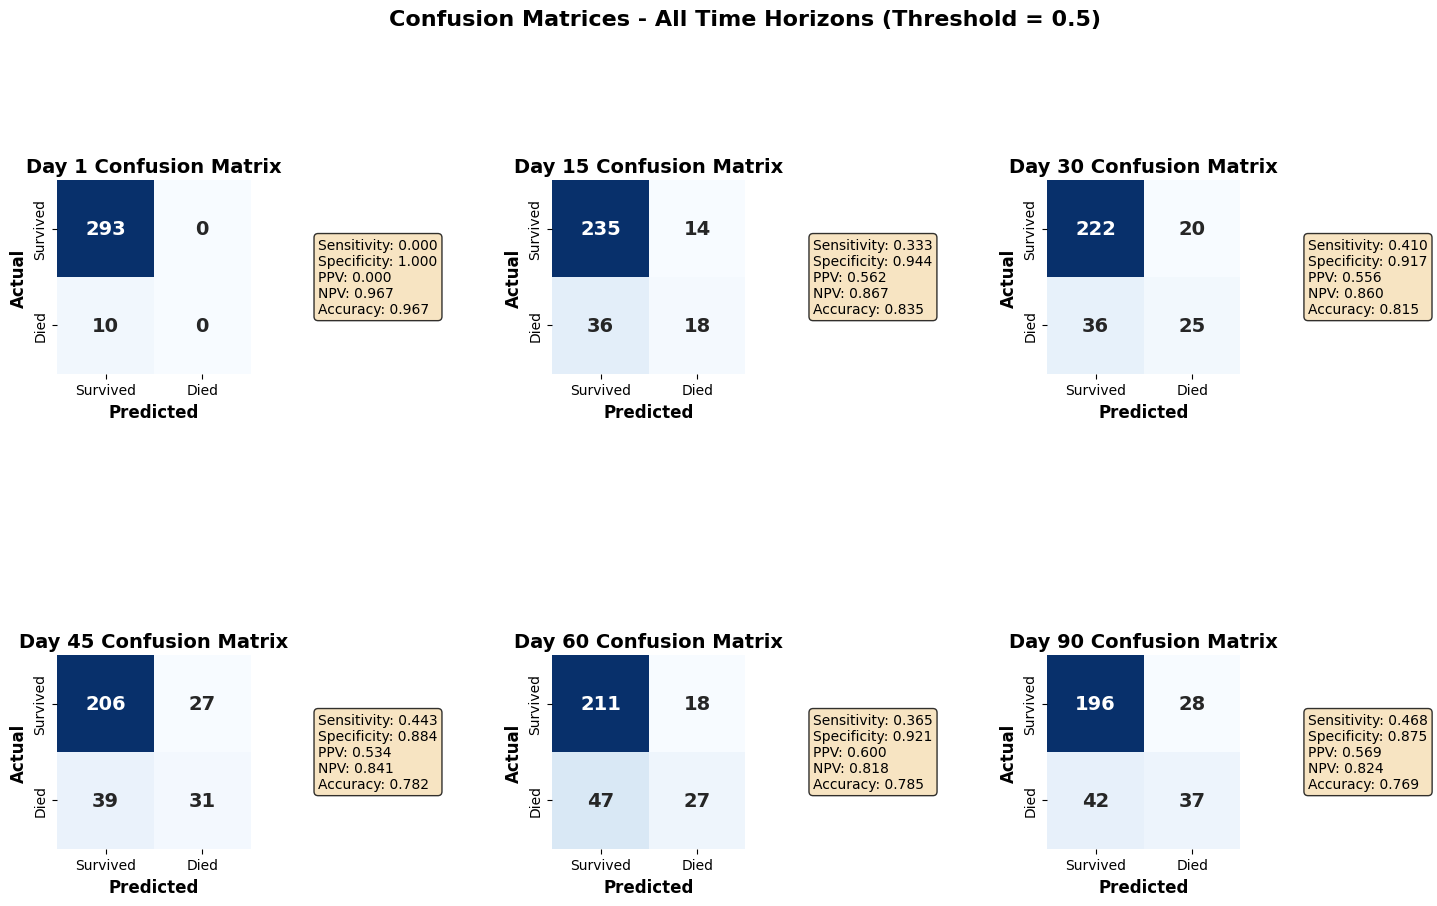

In [ ]:
def plot_confusion_matrices_dl(y_test_multi, y_pred_multi, horizons, threshold=0.5):
    """
    Plot confusion matrices for all time horizons

    Args:
        y_test_multi: List of true labels for each horizon
        y_pred_multi: List of predicted probabilities for each horizon
        horizons: List of time horizons
        threshold: Decision threshold for classification (default 0.5)
    """
    n_horizons = len(horizons)
    n_cols = 3
    n_rows = (n_horizons + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_horizons > 1 else [axes]

    for idx, h in enumerate(horizons):
        ax = axes[idx]

        # Get true labels and predictions
        y_true = y_test_multi[idx]
        y_pred_proba = y_pred_multi[idx].flatten()

        # Apply threshold
        y_pred = (y_pred_proba >= threshold).astype(int)

        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Plot with annotations
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,
            cbar=False,
            square=True,
            annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died']
        )

        ax.set_title(f'Day {h} Confusion Matrix', fontsize=14, fontweight='bold')
        ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')

        # Calculate metrics
        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        # Add metrics text box
        metrics_text = (
            f'Sensitivity: {sensitivity:.3f}\n'
            f'Specificity: {specificity:.3f}\n'
            f'PPV: {ppv:.3f}\n'
            f'NPV: {npv:.3f}\n'
            f'Accuracy: {accuracy:.3f}'
        )

        # Position text box to the right of the heatmap
        ax.text(
            2.7, 1.0, metrics_text,
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            verticalalignment='center',
            transform=ax.transData
        )

    # Remove extra subplots
    for idx in range(n_horizons, len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(f'Confusion Matrices - All Time Horizons (Threshold = {threshold})',
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('deep_learning_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot confusion matrices
plot_confusion_matrices_dl(y_test_multi, y_pred_multi, horizons, threshold=0.5)
def plot_confusion_matrices_dl(y_test_multi, y_pred_multi, horizons, threshold=0.5):
    """
    Plot confusion matrices for all time horizons

    Args:
        y_test_multi: List of true labels for each horizon
        y_pred_multi: List of predicted probabilities for each horizon
        horizons: List of time horizons
        threshold: Decision threshold for classification (default 0.5)
    """
    n_horizons = len(horizons)
    n_cols = 3
    n_rows = (n_horizons + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_horizons > 1 else [axes]

    for idx, h in enumerate(horizons):
        ax = axes[idx]

        # Get true labels and predictions
        y_true = y_test_multi[idx]
        y_pred_proba = y_pred_multi[idx].flatten()

        # Apply threshold
        y_pred = (y_pred_proba >= threshold).astype(int)

        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)

        # Plot with annotations
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,
            cbar=False,
            square=True,
            annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died']
        )

        ax.set_title(f'Day {h} Confusion Matrix', fontsize=14, fontweight='bold')
        ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')

        # Calculate metrics
        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        # Add metrics text box
        metrics_text = (
            f'Sensitivity: {sensitivity:.3f}\n'
            f'Specificity: {specificity:.3f}\n'
            f'PPV: {ppv:.3f}\n'
            f'NPV: {npv:.3f}\n'
            f'Accuracy: {accuracy:.3f}'
        )

        # Position text box to the right of the heatmap
        ax.text(
            2.7, 1.0, metrics_text,
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            verticalalignment='center',
            transform=ax.transData
        )

    # Remove extra subplots
    for idx in range(n_horizons, len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(f'Confusion Matrices - All Time Horizons (Threshold = {threshold})',
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('deep_learning_confusion_matrices.png', dpi=500, bbox_inches='tight')
    plt.show()

# Plot confusion matrices
#plot_confusion_matrices_dl(y_test_multi, y_pred_multi, horizons, threshold=0.5)

### Explainability

###### Using integrated gradients for feature importance calculations

In [ ]:
def compute_integrated_gradients(model, inputs, baseline=None, steps=50):
    """
    Compute Integrated Gradients for feature importance

    Integrated Gradients attribution method:
    - Measures feature importance by integrating gradients along path from baseline to input
    - More reliable than simple gradients
    - Satisfies important axioms (sensitivity, implementation invariance)
    """
    if baseline is None:
        baseline = np.zeros_like(inputs)

    # Generate interpolated inputs
    alphas = np.linspace(0, 1, steps)
    interpolated_inputs = np.array([
        baseline + alpha * (inputs - baseline) for alpha in alphas
    ])

    # Compute gradients
    with tf.GradientTape() as tape:
        inputs_tensor = tf.convert_to_tensor(interpolated_inputs, dtype=tf.float32)
        tape.watch(inputs_tensor)
        predictions = model(inputs_tensor)
        # Sum all outputs (considering all horizons)
        if isinstance(predictions, list):
            predictions = tf.reduce_sum([pred for pred in predictions])

    grads = tape.gradient(predictions, inputs_tensor)

    # Average gradients and compute integrated gradients
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grads = (inputs - baseline) * avg_grads

    return integrated_grads.numpy()

In [ ]:
# Compute for sample patients
print("Gradients for sample patients")
sample_size = min(100, len(X_test_scaled))
sample_indices = np.random.choice(len(X_test_scaled), sample_size, replace=False)
X_sample = X_test_scaled[sample_indices]

Gradients for sample patients


In [ ]:
# Compute attributions
baseline = np.zeros_like(X_sample[0])
attributions = []

for i in range(sample_size):
    attr = compute_integrated_gradients(model, X_sample[i], baseline)
    attributions.append(attr)

attributions = np.array(attributions)
# Average absolute attributions across samples
mean_attributions = np.abs(attributions).mean(axis=0)

In [ ]:
# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': mean_attributions
}).sort_values('Importance', ascending=False)

In [ ]:
print("\nTop 15 Most Important Features (Integrated Gradients):")
print(feature_importance_df.head(15).to_string(index=False))


Top 15 Most Important Features (Integrated Gradients):
              Feature  Importance
            age_group    0.551966
               DOSAGE    0.289848
    sc_History of TIA    0.169493
           race_WHITE    0.153181
sc_Hemorrhagic stroke    0.146173
       race_NON-WHITE    0.125963
            LAB_VALUE    0.121856
         readmissions    0.121063
THERAPEUTIC_PROCEDURE    0.116788
 DETAILED_DESCRIPTION    0.106504
     DISEASE_DISORDER    0.094527
      care_level_high    0.089082
 DIAGNOSTIC_PROCEDURE    0.084316
                Sex_F    0.081844
                Sex_M    0.077722


###### Creating feature importance visualizations

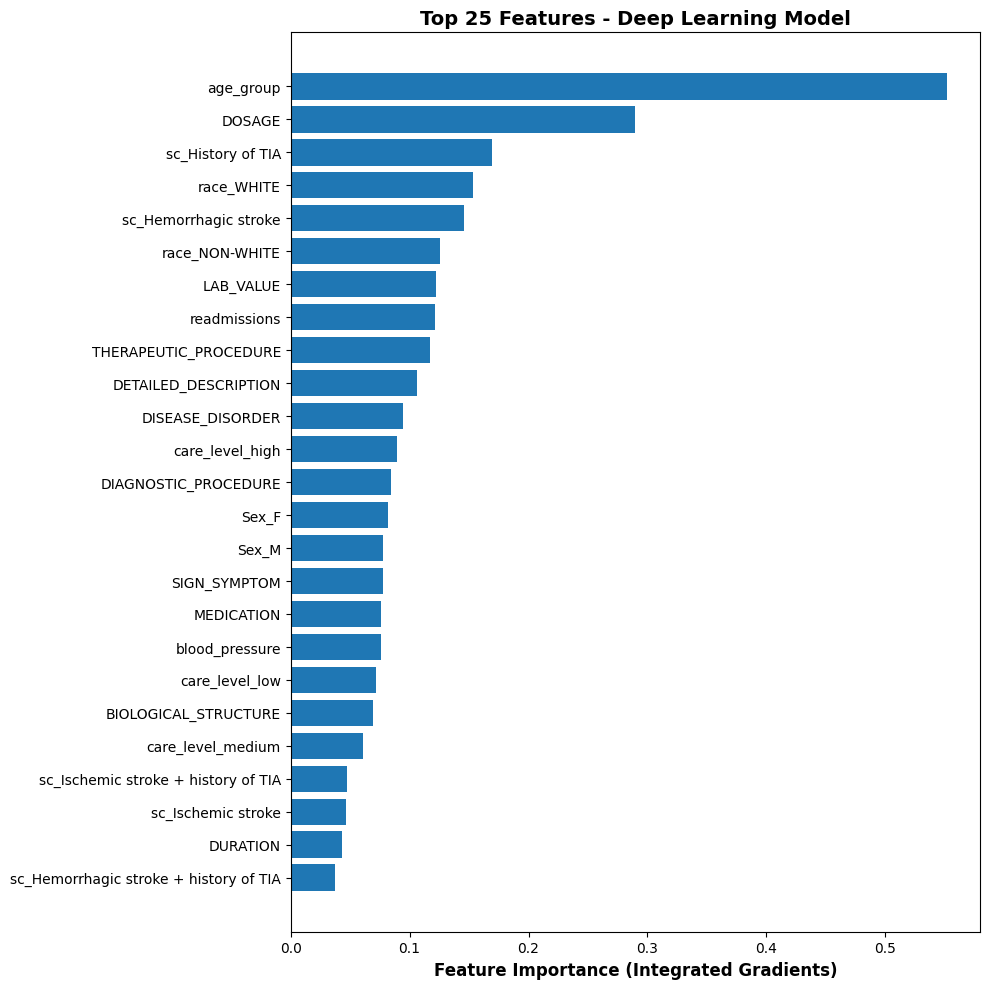

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 10))
top_features = feature_importance_df.head(25)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance (Integrated Gradients)', fontsize=12, fontweight='bold')
plt.title('Top 25 Features - Deep Learning Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('deep_learning_feature_importance.png', dpi=500, bbox_inches='tight')
plt.show()

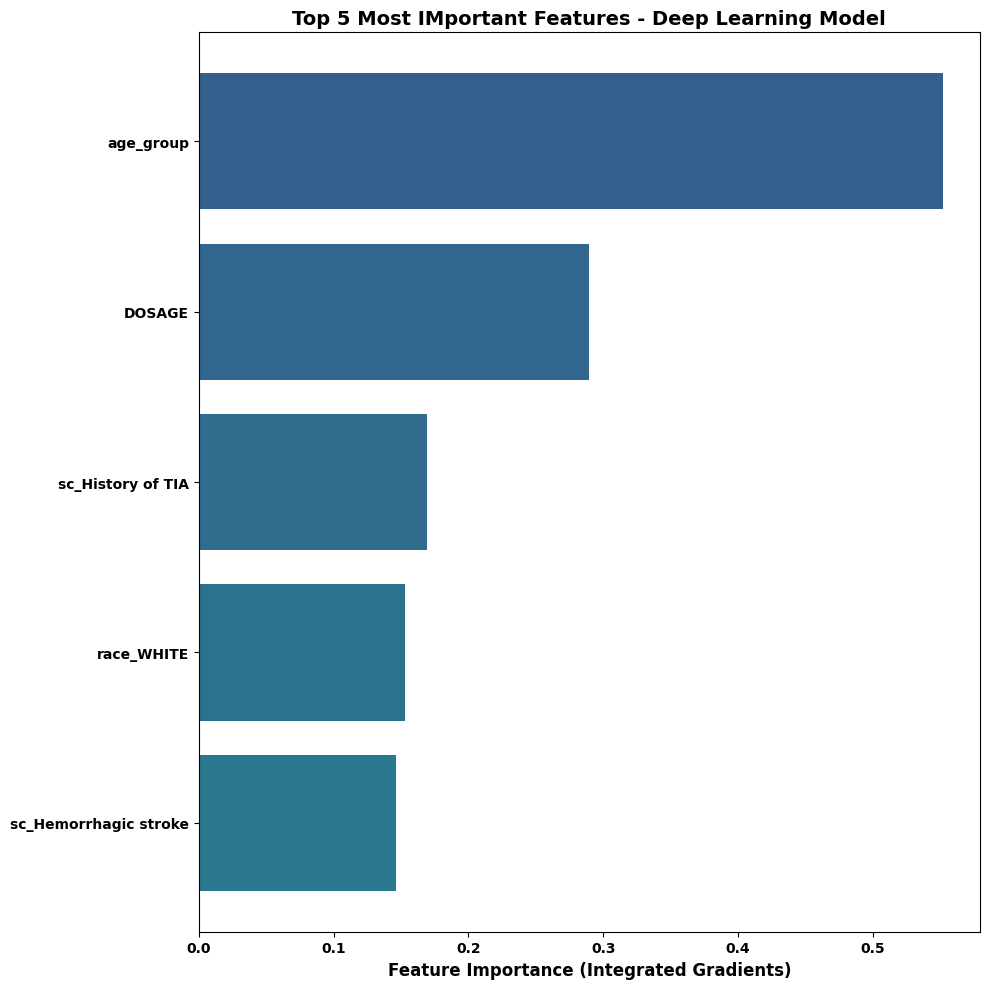

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 10))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
top_features = feature_importance_df.head(5)
plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance (Integrated Gradients)', fontsize=12, fontweight='bold')
plt.title('Top 5 Most IMportant Features - Deep Learning Model', fontsize=14, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_5.png', dpi=500, bbox_inches='tight')
plt.show()

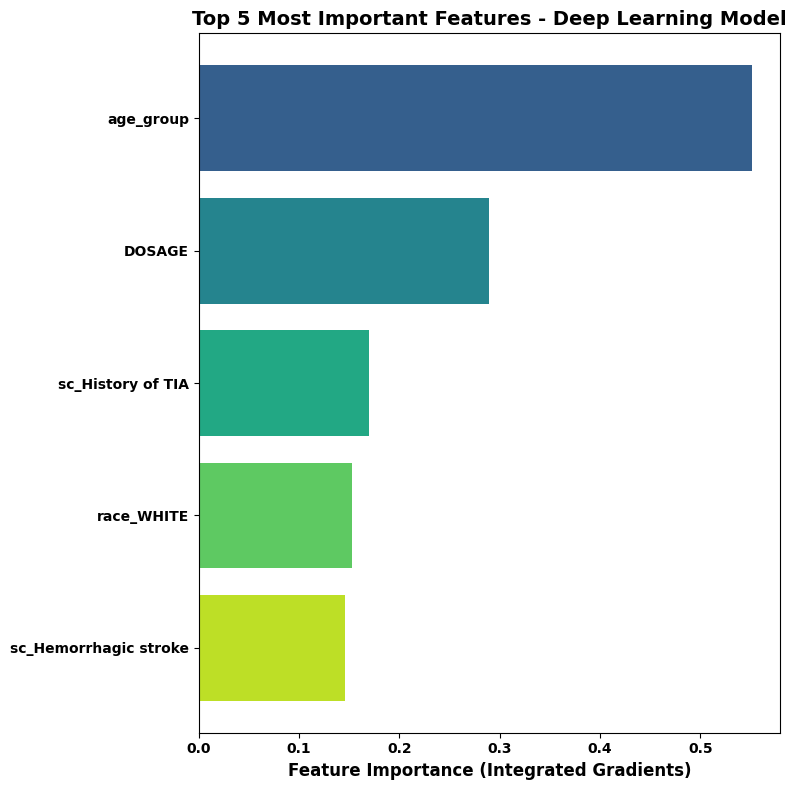

In [ ]:
plt.figure(figsize=(8, 8))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
top_features = feature_importance_df.head(5)

plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance (Integrated Gradients)', fontsize=12, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.title('Top 5 Most Important Features - Deep Learning Model', fontsize=14, fontweight='bold')

plt.gca().invert_yaxis()

# Manually control spacing instead of tight_layout + bbox
plt.subplots_adjust(left=0.4, right=0.95, top=0.9, bottom=0.1)
plt.tight_layout()
plt.savefig('top_5_two.png', dpi=500)
plt.show()

###### SHAP Explanations



In [ ]:
# Pick output index
output_index = horizons.index(30)

# Wrap model to single output
single_output_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.outputs[output_index]
)

# Background
background = X_train_scaled[
    np.random.choice(X_train_scaled.shape[0], 100, replace=False)
]

# SHAP explainer (generic)
explainer_shap = shap.Explainer(
    single_output_model,
    background,
    algorithm="permutation"  # safest for TF
)

# Sample
X_shap_sample = X_test_scaled[:50]

# Compute SHAP values
shap_values = explainer_shap(X_shap_sample)

PermutationExplainer explainer: 51it [00:22,  1.56it/s]


In [ ]:
def make_single_output_model(model, output_idx):
    """Wrap multi-output Keras model to expose a single output."""
    return tf.keras.Model(
        inputs=model.input,
        outputs=model.outputs[output_idx])

In [ ]:
# prediction horizon (1 day)
horizon_to_explain = 1
output_idx = horizons.index(horizon_to_explain)

In [ ]:
# Background set
background_size = 800
background = X_train_scaled[
    np.random.choice(X_train_scaled.shape[0], background_size, replace=False)]

In [ ]:
# Single-output model
horizon_model = make_single_output_model(model, output_idx)

In [ ]:
# SHAP explainer (robust for TF + multi-output)
explainer = shap.Explainer(horizon_model, background, algorithm="permutation")

In [ ]:
feature_names = X_train.columns.tolist()

PermutationExplainer explainer: 304it [01:55,  2.37it/s]


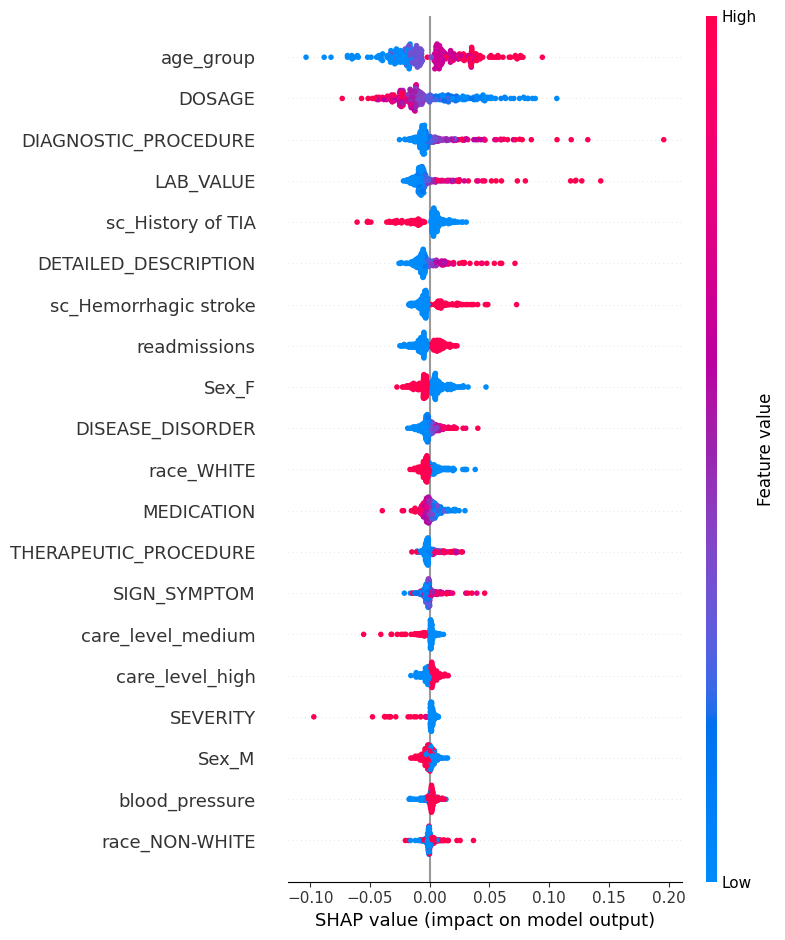

In [ ]:
# Sample test set for visualization
shap_sample_size = 303
X_shap_sample = X_test_scaled[np.random.choice(X_test_scaled.shape[0], shap_sample_size, replace=False)]

# Compute SHAP values
shap_values = explainer(X_shap_sample)

# Global importance
shap.summary_plot(shap_values.values, X_shap_sample, feature_names=feature_names, show=True)
plt.title('Feature Effects on 1-Day Mortality Risk', fontsize=14, fontweight='bold')
plt.xlabel('SHAP value', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.savefig('dl_shap_one.png', dpi=500, bbox_inches='tight')

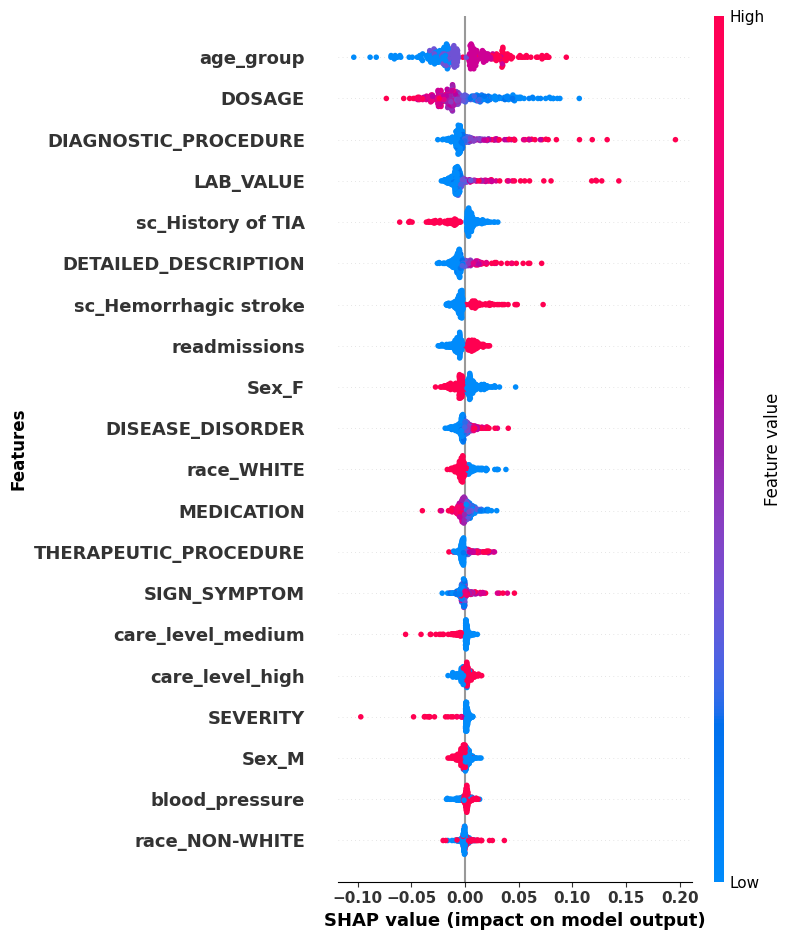

In [ ]:
shap.summary_plot(shap_values.values, X_shap_sample, feature_names=feature_names, show=True)
plt.title('', fontsize=14, fontweight='bold')
plt.xlabel('SHAP value', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.savefig('dl_shap_one.png', dpi=500, bbox_inches='tight')

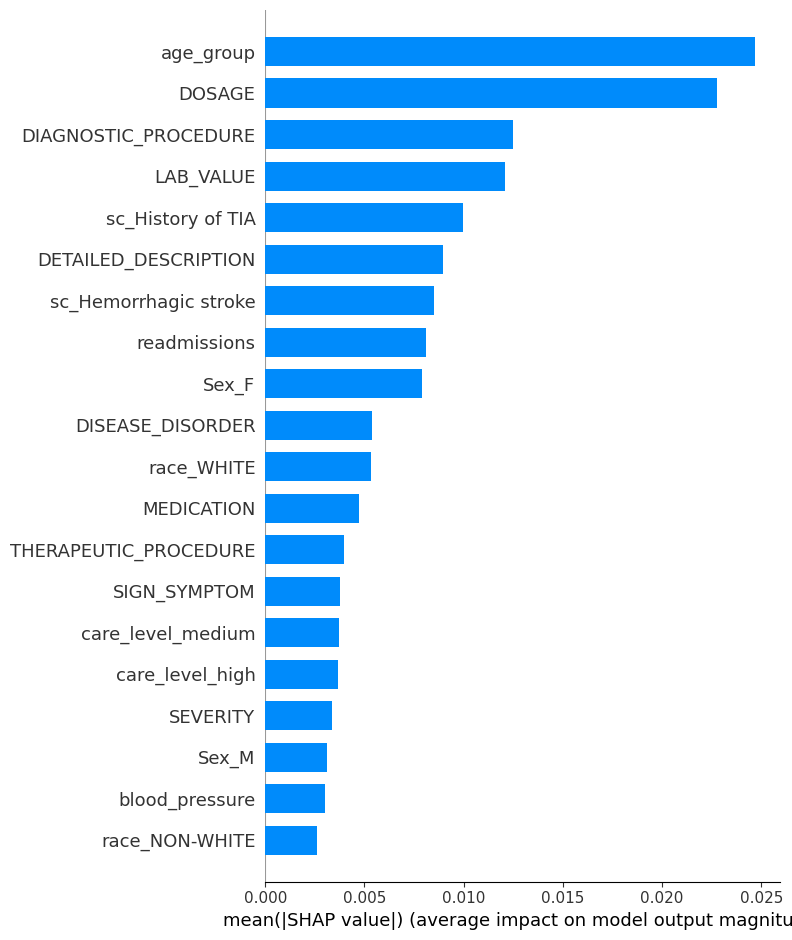

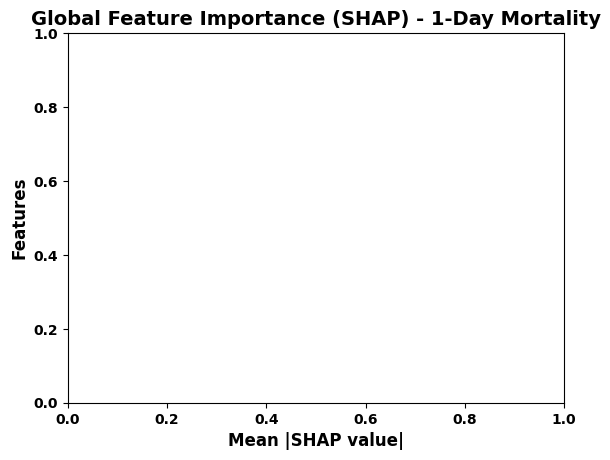

In [ ]:
shap.summary_plot(shap_values.values, X_shap_sample, feature_names=feature_names, plot_type="bar",show=True)
plt.xlabel('Mean |SHAP value|', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.title('Global Feature Importance (SHAP) - 1-Day Mortality', fontsize=14, fontweight='bold')
plt.savefig('dl_shap_two.png', dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
# Pick one patient / individual
individual_idx = 0
X_individual = X_test_scaled[individual_idx:individual_idx + 1]

In [ ]:
shap_individual = explainer(X_individual)

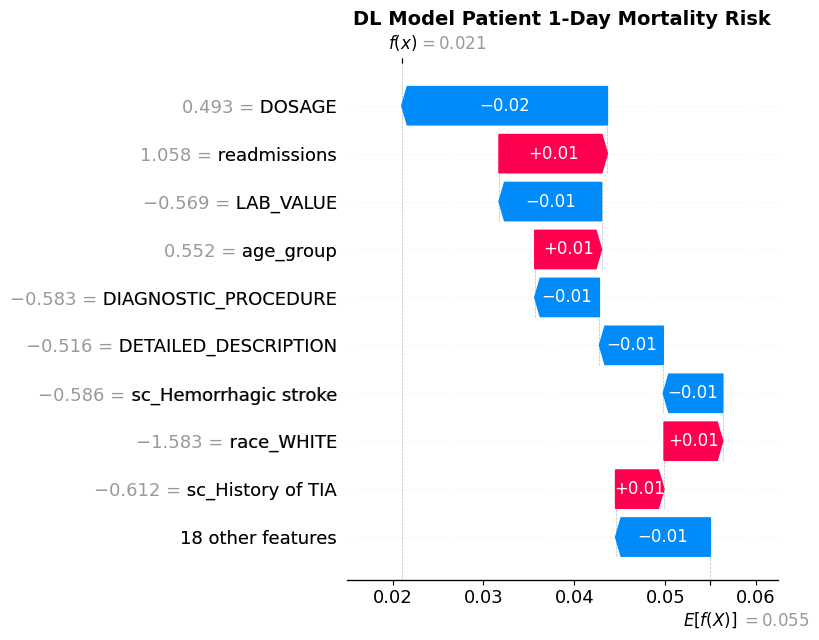

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_individual.values[0],
        base_values=shap_individual.base_values[0],
        data=X_individual[0],
        feature_names=feature_names
    ),
    show=False  # important!
)

plt.title("DL Model Patient 1-Day Mortality Risk", fontsize=14, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.savefig('dl_shap_three.png', dpi=500, bbox_inches='tight')
plt.show()

###### Add LIME Explanations

In [ ]:
class MultiTaskLIMEExplainer:
    """
    LIME Explainer for multi-task survival analysis models.
    Each output (time horizon) is explained separately.
    """

    def __init__(self, model, X_train, feature_names, horizons, scaler=None):
        """
        Initialize the LIME explainer.

        Args:
            model: Trained Keras multi-output model
            X_train: Training data (numpy array or DataFrame) for reference distribution
            feature_names: List of feature names
            horizons: List of prediction horizons (e.g., [1, 7, 15, 30, 60, 90])
            scaler: Optional StandardScaler if features need scaling
        """
        self.model = model
        self.X_train = X_train if isinstance(X_train, np.ndarray) else X_train.values
        self.feature_names = feature_names
        self.horizons = horizons
        self.scaler = scaler

        # Create LIME explainer for tabular data
        self.explainer = lime_tabular.LimeTabularExplainer(
            training_data=self.X_train,
            feature_names=self.feature_names,
            mode='regression',  # Use regression mode for probability outputs
            verbose=False
        )

    def _predict_fn_for_horizon(self, horizon_idx):
        """
        Create a prediction function for a specific time horizon.
        LIME needs a function that takes raw features and returns predictions.

        Args:
            horizon_idx: Index of the horizon to explain

        Returns:
            Function that predicts for the given horizon
        """
        def predict_fn(X):
            """
            Prediction function that LIME will call.

            Args:
                X: numpy array of shape (n_samples, n_features)

            Returns:
                numpy array of shape (n_samples,) with predictions
            """
            # Scale if scaler is provided
            if self.scaler is not None:
                X_scaled = self.scaler.transform(X)
            else:
                X_scaled = X

            # Get predictions from model (list of outputs)
            predictions = self.model.predict(X_scaled, verbose=0)

            # Extract the specific horizon's predictions
            horizon_predictions = predictions[horizon_idx]

            # Flatten to 1D array
            return horizon_predictions.flatten()

        return predict_fn

    def explain_patient(self, patient_data, horizon_idx=0, num_features=10):
        """
        Explain a single patient's prediction for a specific horizon.

        Args:
            patient_data: Single patient as numpy array (1D) or DataFrame row
            horizon_idx: Index of horizon to explain (default: 0 for first horizon)
            num_features: Number of top features to show in explanation

        Returns:
            LIME explanation object
        """
        # Convert to numpy array if needed
        if isinstance(patient_data, pd.DataFrame):
            patient_data = patient_data.values[0]
        elif isinstance(patient_data, pd.Series):
            patient_data = patient_data.values

        # Get prediction function for this horizon
        predict_fn = self._predict_fn_for_horizon(horizon_idx)

        # Generate LIME explanation
        explanation = self.explainer.explain_instance(
            data_row=patient_data,
            predict_fn=predict_fn,
            num_features=num_features,
            num_samples=5000  # Number of perturbed samples for LIME
        )

        return explanation

    def plot_explanation(self, explanation, horizon_idx, patient_idx=0,
                        save_path=None, figsize=(10, 6)):
        """
        Create a visualization of the LIME explanation.

        Args:
            explanation: LIME explanation object
            horizon_idx: Index of the horizon being explained
            patient_idx: Patient identifier for the title
            save_path: Optional path to save the figure
            figsize: Figure size tuple
        """
        # Get feature importance from LIME
        feature_importance = explanation.as_list()

        # Sort by absolute importance
        feature_importance = sorted(feature_importance,
                                   key=lambda x: abs(x[1]),
                                   reverse=True)

        # Extract features and values
        features = [f[0] for f in feature_importance]
        values = [f[1] for f in feature_importance]

        # Create color map (positive = red, negative = blue)
        colors = ['#d62728' if v > 0 else '#1f77b4' for v in values]

        # Create horizontal bar plot
        fig, ax = plt.subplots(figsize=figsize)

        y_pos = np.arange(len(features))
        ax.barh(y_pos, values, color=colors, alpha=0.8)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(features, fontweight='bold')
        ax.set_xlabel('LIME Feature Importance', fontsize=12, fontweight='bold')
        ax.set_title(f'Patient {patient_idx + 1} - {self.horizons[horizon_idx]}-Day Mortality Risk\n'
                    f'LIME Explanation',
                    fontsize=14, fontweight='bold')

        # Add vertical line at 0
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#d62728', alpha=0.8, label='Increases Risk'),
            Patch(facecolor='#1f77b4', alpha=0.8, label='Decreases Risk')
        ]
        ax.legend(handles=legend_elements, loc='best', frameon=True)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Figure saved to {save_path}")

        plt.show()

        return fig, ax

    def explain_all_horizons(self, patient_data, patient_idx=0, num_features=10,
                            save_prefix='lime_patient'):
        """
        Explain all time horizons for a single patient.

        Args:
            patient_data: Single patient data
            patient_idx: Patient identifier
            num_features: Number of features to show
            save_prefix: Prefix for saved figure files

        Returns:
            List of explanation objects
        """
        explanations = []

        for i, horizon in enumerate(self.horizons):
            print(f"\nGenerating LIME explanation for {horizon}-day horizon...")

            # Generate explanation
            exp = self.explain_patient(patient_data, horizon_idx=i,
                                      num_features=num_features)
            explanations.append(exp)

            # Plot explanation
            save_path = f'{save_prefix}_{patient_idx+1}_horizon_{horizon}days.png'
            self.plot_explanation(exp, horizon_idx=i, patient_idx=patient_idx,
                                save_path=save_path)

        return explanations

    def compare_with_actual_prediction(self, patient_data, horizon_idx=0):
        """
        Compare LIME's local model with actual model prediction.

        Args:
            patient_data: Single patient data
            horizon_idx: Index of horizon to compare

        Returns:
            Dictionary with actual and LIME predictions
        """
        # Convert to numpy if needed
        if isinstance(patient_data, pd.DataFrame):
            patient_array = patient_data.values[0]
        elif isinstance(patient_data, pd.Series):
            patient_array = patient_data.values
        else:
            patient_array = patient_data

        # Get actual prediction
        if self.scaler is not None:
            patient_scaled = self.scaler.transform(patient_array.reshape(1, -1))
        else:
            patient_scaled = patient_array.reshape(1, -1)

        actual_predictions = self.model.predict(patient_scaled, verbose=0)
        actual_pred = float(actual_predictions[horizon_idx][0, 0])

        # Get LIME explanation
        explanation = self.explain_patient(patient_array, horizon_idx=horizon_idx)

        # LIME's local prediction
        lime_pred = explanation.local_pred[0] if hasattr(explanation, 'local_pred') else None

        # Get prediction from LIME's model
        predict_fn = self._predict_fn_for_horizon(horizon_idx)
        lime_model_pred = predict_fn(patient_array.reshape(1, -1))[0]

        return {
            'actual_prediction': actual_pred,
            'lime_local_prediction': lime_pred,
            'lime_model_prediction': lime_model_pred,
            'horizon_days': self.horizons[horizon_idx],
            'explanation': explanation
        }


def create_lime_comparison_plot(explainer, patient_data, save_path='lime_comparison.png'):
    """
    Create a comparison plot showing predictions across all horizons.

    Args:
        explainer: MultiTaskLIMEExplainer instance
        patient_data: Single patient data
        save_path: Path to save the figure
    """
    results = []

    for i in range(len(explainer.horizons)):
        comparison = explainer.compare_with_actual_prediction(patient_data, horizon_idx=i)
        results.append(comparison)

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    horizons = [r['horizon_days'] for r in results]
    actual_preds = [r['actual_prediction'] for r in results]
    lime_preds = [r['lime_model_prediction'] for r in results]

    ax.plot(horizons, actual_preds, marker='o', linewidth=2,
            markersize=8, label='Actual Model', color='#d62728')
    ax.plot(horizons, lime_preds, marker='s', linewidth=2,
            markersize=8, label='LIME Approximation',
            color='#1f77b4', linestyle='--')

    ax.set_xlabel('Prediction Horizon (Days)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mortality Risk Probability', fontsize=12, fontweight='bold')
    ax.set_title('Model vs LIME Predictions Across Time Horizons',
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, frameon=True)
    ax.grid(True, alpha=0.3)

    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nComparison plot saved to {save_path}")
    plt.show()

    return results

In [ ]:
lime_explainer = MultiTaskLIMEExplainer(model=model,X_train=X_train_scaled,feature_names=feature_names,
                                        horizons=horizons,scaler=None)

In [ ]:
# Explain first patient
first_patient = X_test_scaled[0]
explanation = lime_explainer.explain_patient(patient_data=first_patient,horizon_idx=0,num_features=10)

In [ ]:
# In the explainer initialization
lime_explainer = MultiTaskLIMEExplainer(model=model,X_train=X_train_scaled,
    feature_names=feature_names,horizons=[1, 7, 15, 30, 60, 90],scaler=None)

explanation = lime_explainer.explain_patient(patient_data=first_patient, horizon_idx=0,
    num_features=10)

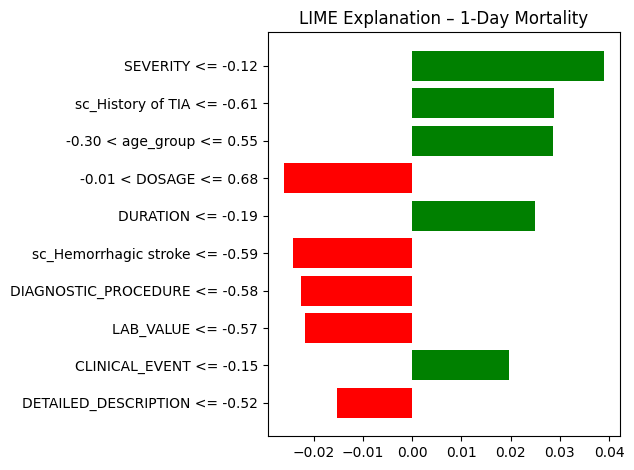

In [ ]:
fig = explanation.as_pyplot_figure()
plt.title("LIME Explanation – 1-Day Mortality")
plt.tight_layout()
plt.show()